<a href="https://colab.research.google.com/github/shin-noda/deep-learning-with-python/blob/main/Chapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [151]:
# Constant tensors
import tensorflow as tf

tf.ones(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[1.],
       [1.]], dtype=float32)>

In [152]:
tf.zeros(shape=(2, 1))

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.],
       [0.]], dtype=float32)>

In [153]:
tf.constant([1, 2, 3], dtype="float32")

<tf.Tensor: shape=(3,), dtype=float32, numpy=array([1., 2., 3.], dtype=float32)>

In [154]:
# Random tensors
x = tf.random.normal(shape=(3, 1), mean=0., stddev=1.)
print(x)

tf.Tensor(
[[-0.9081488 ]
 [ 0.05297389]
 [-0.3774568 ]], shape=(3, 1), dtype=float32)


In [155]:
x = tf.random.uniform(shape=(3, 1), minval=0., maxval=1.)
print(x)

tf.Tensor(
[[0.34965098]
 [0.23750246]
 [0.89497566]], shape=(3, 1), dtype=float32)


In [156]:
# Tensor assignment and the Variable class
import numpy as np

x = np.ones(shape=(2, 2))
x[0, 0] = 0.0

In [157]:
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[-0.19216534],
       [-0.01872686],
       [ 0.44066623]], dtype=float32)>


In [158]:
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [159]:
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [160]:
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

In [161]:
time = tf.Variable(0.0)
with tf.GradientTape() as outer_tape:
    with tf.GradientTape() as inner_tape:
        position = 4.9 * time**2

    speed = inner_tape.gradient(position, time)

# We use the outer tape to compute the gradient of the gradient from the inner tape.
# Natually, the answer is 4.9 * 2 = 9.8
acceleration = outer_tape.gradient(speed, time)

# Use .numpy() to extract the raw scalar
print(acceleration.numpy())

9.8


In [162]:
# Apply compilation by wrapping it in a tf.function decorator
@tf.function
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

In [163]:
@tf.function(jit_compile=True)
def dense(inputs, W, b):
    return tf.nn.relu(tf.matmul(inputs, W) + b)

In [164]:
# A linear classifier in pure TensorFlow

In [165]:
import numpy as np

num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0], cov=[[1, 0.5], [0.5, 1]], size=num_samples_per_class
)

In [166]:
# Stack negative and positive samples into a single array
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [167]:
# Generate the corresponding target labels
targets = np.vstack(
    (
        np.zeros((num_samples_per_class, 1), dtype="float32"),
        np.ones((num_samples_per_class, 1), dtype="float32"),
    )
)

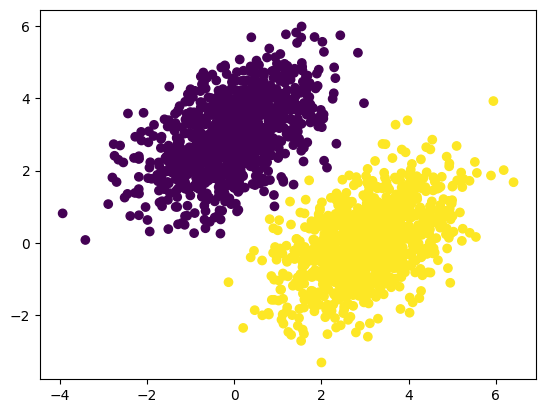

In [168]:
import matplotlib.pyplot as plt

plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [169]:
# The inputs will be 2D points
input_dim = 2

# The output predictions will be a single score per sample
# (close to 0 if the sample is predicted to be in class 0, and
# close to 1 if the sample is predicted to be in class 1).
output_dim = 1

W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [170]:
# Our forward pass function
def model(inputs, W, b):
    return tf.matmul(inputs, W) + b

In [171]:
# Our loss function
def mean_squared_error(targets, predictions):
    # per_sample_losses will be a tensor with the same shape as targets
    # and predictions, containing per-sample loss scores.
    per_sample_losses = tf.square(targets - predictions)

    # We need to average these per-sample loss scores into a single
    # scalar loss value: reduce_mean does this.
    return tf.reduce_mean(per_sample_losses)

In [172]:
learning_rate = 0.1

# Wraps the function in a tf.function decorator to speed it up
@tf.function(jit_compile=True)
def training_step(inputs, targets, W, b):
    # Forward pass, inside of a gradient tape scope
    with tf.GradientTape() as tape:
        predictions = model(inputs, W, b)
        loss = mean_squared_error(predictions, targets)

    # Retrieves the gradient of the loss with regard to weights
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])

    # Updates the weights
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)

    return loss

In [173]:
for step in range(40):
    loss = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 0.0896
Loss at step 1: 0.0827
Loss at step 2: 0.0776
Loss at step 3: 0.0729
Loss at step 4: 0.0687
Loss at step 5: 0.0648
Loss at step 6: 0.0613
Loss at step 7: 0.0581
Loss at step 8: 0.0552
Loss at step 9: 0.0525
Loss at step 10: 0.0501
Loss at step 11: 0.0479
Loss at step 12: 0.0459
Loss at step 13: 0.0440
Loss at step 14: 0.0423
Loss at step 15: 0.0408
Loss at step 16: 0.0394
Loss at step 17: 0.0381
Loss at step 18: 0.0370
Loss at step 19: 0.0359
Loss at step 20: 0.0350
Loss at step 21: 0.0341
Loss at step 22: 0.0333
Loss at step 23: 0.0325
Loss at step 24: 0.0319
Loss at step 25: 0.0313
Loss at step 26: 0.0307
Loss at step 27: 0.0302
Loss at step 28: 0.0297
Loss at step 29: 0.0293
Loss at step 30: 0.0289
Loss at step 31: 0.0286
Loss at step 32: 0.0283
Loss at step 33: 0.0280
Loss at step 34: 0.0277
Loss at step 35: 0.0275
Loss at step 36: 0.0273
Loss at step 37: 0.0271
Loss at step 38: 0.0269
Loss at step 39: 0.0267


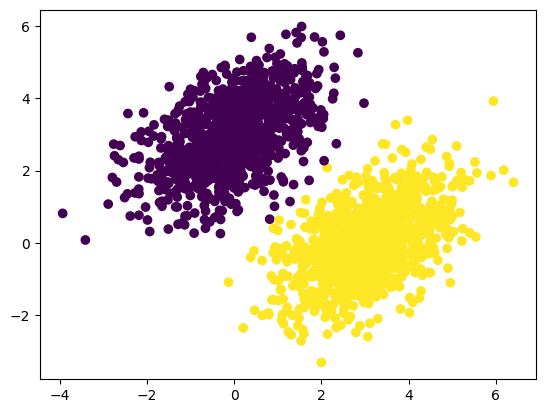

In [174]:
predictions = model(inputs, W, b)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

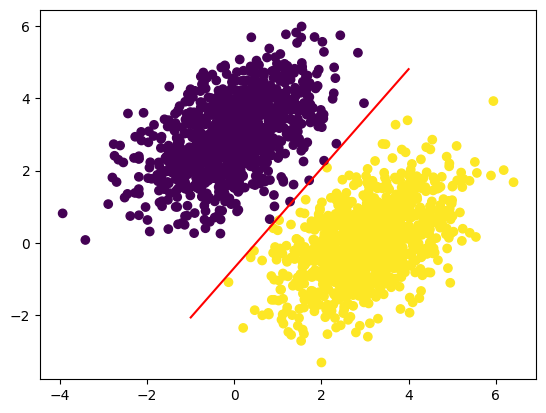

In [175]:
# Generate 100 regularly space numbers between -1 and 4, which we
# will use to plot our line
x = np.linspace(-1, 4, 100)

# This is our line's equation
y = -W[0] / W[1] * x + (0.5 - b) / W[1]

# Plots our line (`"-r" means "plot it as a red line")
plt.plot(x, y, "-r")

# Plots our model's predictions on the same plot
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

In [176]:
# PyTorch

In [177]:
# A linear classifier in PyTorch

In [178]:
import torch

# Note: Don't forget to pass 'required_grad=True' so
# we can compute gradients with respect to them
input_dim = 2
output_dim = 1

W = torch.rand(input_dim, output_dim, requires_grad=True)
b = torch.zeros(output_dim, requires_grad=True)

In [179]:
def model(inputs, W, b):
    return torch.matmul(inputs, W) + b

In [180]:
def mean_squared_error(targets, predictions):
    per_sample_losses = torch.square(targets - predictions)
    return torch.mean(per_sample_losses)

In [181]:
learning_rate = 0.1

def training_step(inputs, targets, W, b):
    # Forward pass
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)

    # Computes gradients
    loss.backward()

    # Retrieves gradients
    grad_loss_wrt_W, grad_loss_wrt_b = W.grad, b.grad
    with torch.no_grad():
        # Updates weights inside a no_grad scope
        W -= grad_loss_wrt_W * learning_rate
        b -= grad_loss_wrt_b * learning_rate

    # Resets gradients
    W.grad = None
    b.grad = None

    return loss

In [182]:
import torch

class LinearModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.W = torch.nn.Parameter(torch.rand(input_dim, output_dim))
        self.b = torch.nn.Parameter(torch.zeros(output_dim))


    def forward(self, inputs):
        return torch.matmul(inputs, self.W) + self.b

In [183]:
model = LinearModel()

In [184]:
torch_inputs = torch.tensor(inputs)
output = model(torch_inputs)

In [185]:
print(torch_inputs.shape)
print(output.shape)

torch.Size([2000, 2])
torch.Size([2000, 1])


In [186]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [187]:
def training_step(inputs, targets):
    predictions = model(inputs)
    loss = mean_squared_error(targets, predictions)
    loss.backward()
    optimizer.step()
    model.zero_grad()

    return loss

In [188]:
# Use the Dynamo compiler
compiled_model = torch.compile(model)

In [189]:
@torch.compile
def dense(inputs, W, b):
    return torch.nn.relu(torch.matmul(inputs, W) + b)

In [190]:
torch_targets = torch.tensor(targets)

In [191]:
for step in range(40):
    loss = training_step(torch_inputs, torch_targets)

    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 0.1717
Loss at step 1: 0.0952
Loss at step 2: 0.0842
Loss at step 3: 0.0785
Loss at step 4: 0.0737
Loss at step 5: 0.0694
Loss at step 6: 0.0655
Loss at step 7: 0.0619
Loss at step 8: 0.0586
Loss at step 9: 0.0557
Loss at step 10: 0.0530
Loss at step 11: 0.0505
Loss at step 12: 0.0483
Loss at step 13: 0.0462
Loss at step 14: 0.0443
Loss at step 15: 0.0426
Loss at step 16: 0.0411
Loss at step 17: 0.0396
Loss at step 18: 0.0384
Loss at step 19: 0.0372
Loss at step 20: 0.0361
Loss at step 21: 0.0351
Loss at step 22: 0.0342
Loss at step 23: 0.0334
Loss at step 24: 0.0327
Loss at step 25: 0.0320
Loss at step 26: 0.0314
Loss at step 27: 0.0308
Loss at step 28: 0.0303
Loss at step 29: 0.0298
Loss at step 30: 0.0294
Loss at step 31: 0.0290
Loss at step 32: 0.0287
Loss at step 33: 0.0283
Loss at step 34: 0.0280
Loss at step 35: 0.0278
Loss at step 36: 0.0275
Loss at step 37: 0.0273
Loss at step 38: 0.0271
Loss at step 39: 0.0269


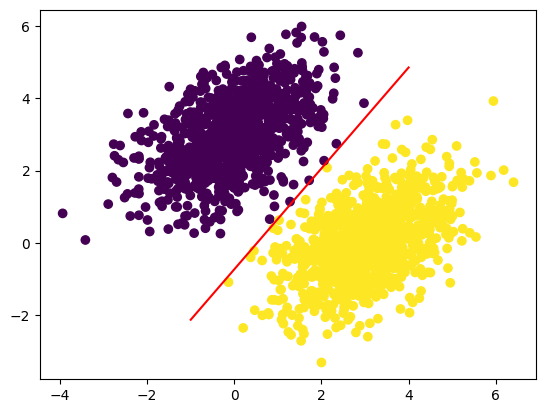

In [192]:
# We're just using the model, so don't build the gradient-tracking machinery for this.
with torch.no_grad():
    predictions = model(torch_inputs)

predictions = predictions.numpy()
inputs_np = torch_inputs.numpy()

plt.scatter(inputs_np[:, 0], inputs_np[:, 1], c=predictions[:, 0] > 0.5)

x = np.linspace(-1, 4, 100)

W = model.W.detach().numpy()
b = model.b.detach().numpy()

w1 = W[0, 0]
w2 = W[1, 0]
bias = b[0]

y = -w1 / w2 * x + (0.5 - bias) / w2

plt.plot(x, y, "-r")
plt.show()

In [193]:
# JAX

In [194]:
# A linear classifier in JAX

In [195]:
from jax import numpy as jnp

In [196]:
def model(inputs, W, b):
    return jnp.matmul(inputs, W) + b


def mean_squared_error(targets, predictions):
    per_sample_losses = jnp.square(targets - predictions)
    return jnp.mean(per_sample_losses)

In [197]:
def compute_loss(state, inputs, targets):
    W, b = state
    predictions = model(inputs, W, b)
    loss = mean_squared_error(targets, predictions)

    return loss

In [198]:
import jax

grad_fn = jax.value_and_grad(compute_loss)

In [199]:
learning_rate = 0.1

# We use the jax.jit decorator to take advantage of XLA compilation
@jax.jit
def training_step(inputs, targets, W, b):
    # Computes the forward pass and backward pass in one go
    loss, grads = grad_fn((W, b), inputs, targets)
    grad_wrt_W, grad_wrt_b = grads

    # Updates W and b
    W = W - grad_wrt_W * learning_rate
    b = b - grad_wrt_b * learning_rate

    # Make sure to return the new values of W and b in addition to the loss
    return loss, W, b

In [200]:
input_dim = 2
output_dim = 1

W = jax.numpy.array(np.random.uniform(size=(input_dim, output_dim)))
b = jax.numpy.array(np.zeros(shape=(output_dim,)))
state = (W, b)

for step in range(40):
    loss, W, b = training_step(inputs, targets, W, b)
    print(f"Loss at step {step}: {loss:.4f}")

Loss at step 0: 0.8282
Loss at step 1: 0.1889
Loss at step 2: 0.1111
Loss at step 3: 0.0962
Loss at step 4: 0.0890
Loss at step 5: 0.0833
Loss at step 6: 0.0781
Loss at step 7: 0.0735
Loss at step 8: 0.0692
Loss at step 9: 0.0653
Loss at step 10: 0.0617
Loss at step 11: 0.0585
Loss at step 12: 0.0555
Loss at step 13: 0.0528
Loss at step 14: 0.0504
Loss at step 15: 0.0482
Loss at step 16: 0.0461
Loss at step 17: 0.0442
Loss at step 18: 0.0425
Loss at step 19: 0.0410
Loss at step 20: 0.0396
Loss at step 21: 0.0383
Loss at step 22: 0.0371
Loss at step 23: 0.0361
Loss at step 24: 0.0351
Loss at step 25: 0.0342
Loss at step 26: 0.0334
Loss at step 27: 0.0326
Loss at step 28: 0.0320
Loss at step 29: 0.0313
Loss at step 30: 0.0308
Loss at step 31: 0.0303
Loss at step 32: 0.0298
Loss at step 33: 0.0294
Loss at step 34: 0.0290
Loss at step 35: 0.0286
Loss at step 36: 0.0283
Loss at step 37: 0.0280
Loss at step 38: 0.0278
Loss at step 39: 0.0275


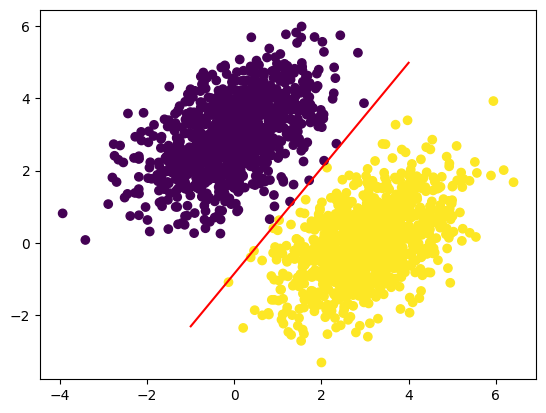

In [201]:
# Get predictions from the trained JAX model
predictions = model(inputs, W, b)

# Convert JAX array to NumPy
predictions = np.array(predictions)

# Plot predictions
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

# Generate 100 regularly spaced x values
x = np.linspace(-1, 4, 100)

# Extract trained parameters
w1, w2, bias = W[0, 0], W[1, 0], b[0]

# Decision boundary
y = -w1 / w2 * x + (0.5 - bias) / w2

# Plot thile line
plt.plot(x, y, "-r")

plt.show()

In [203]:
import os

# Sets the environment variable from within the Python runtime
os.environ["KERAS_BACKEND"] = "jax"

In [204]:
import keras

# All Keras layers inherit from the base Layer class.
class SimpleDense(keras.Layer):
    def __init__(self, units, activation=None):
        super().__init__()
        self.units = units
        self.activation = activation


    # Weight creation takes place in the build() method.
    def build(self, input_shape):
        batch_dim, input_dim = input_shape

        # add_weight is a shortcut method for creating weights.
        # It's also possible to create standalone variables and assign them
        # as layer attributes, like self.W = keras.Variable(shape=..., initializer=...)
        self.W = self.add_weight(shape=(input_dim, self.units), initializer="random_normal")
        self.b = self.add_weight(shape=(self.units), initializer="zeros")


    # We define the forward pass computation in the call() method.
    def call(self, inputs):
        y = keras.ops.matmul(input, self.W) + self.b
        if self.activation is not None:
            y = self.activation(y)

        return y